In [ ]:
import random
import json
from collections import defaultdict
from datasets import load_dataset

# ------------------------------------------------------------
# OCR confusions (same as approved)
# ------------------------------------------------------------
OCR_CONFUSIONS = {
    'o': [('0', 0.5), ('O', 0.2), ('c', 0.15), ('a', 0.15)],
    'O': [('0', 0.5), ('o', 0.2), ('Q', 0.15), ('C', 0.15)],
    'l': [('1', 0.5), ('I', 0.3), ('i', 0.2)],
    'I': [('1', 0.5), ('l', 0.3), ('i', 0.2)],
    'i': [('1', 0.3), ('l', 0.3), ('I', 0.3), ('j', 0.1)],
    's': [('5', 0.5), ('S', 0.2), ('$', 0.15), ('z', 0.15)],
    'S': [('5', 0.5), ('s', 0.2), ('$', 0.15), ('8', 0.15)],
    'z': [('2', 0.5), ('Z', 0.2), ('s', 0.3)],
    'Z': [('2', 0.5), ('z', 0.2), ('S', 0.3)],
    'B': [('8', 0.5), ('b', 0.2), ('R', 0.15), ('E', 0.15)],
    'b': [('8', 0.3), ('6', 0.3), ('B', 0.2), ('h', 0.2)],
    'g': [('9', 0.5), ('q', 0.2), ('y', 0.2), ('a', 0.1)],
    'q': [('9', 0.5), ('g', 0.2), ('O', 0.2), ('a', 0.1)],
    'c': [('e', 0.4), ('o', 0.3), ('C', 0.2), ('(', 0.1)],
    'e': [('c', 0.4), ('o', 0.3), ('a', 0.2), ('8', 0.1)],
    'n': [('h', 0.4), ('m', 0.3), ('r', 0.2), ('u', 0.1)],
    'h': [('n', 0.4), ('b', 0.3), ('k', 0.15), ('L', 0.15)],
    'm': [('n', 0.5), ('w', 0.2)],
    'r': [('n', 0.3), ('t', 0.3), ('f', 0.2), ('l', 0.2)],
    'd': [('o', 0.3), ('c', 0.3)],
    'w': [('v', 0.4), ('W', 0.2)],
    'v': [('y', 0.3), ('V', 0.2), ('w', 0.3), ('u', 0.2)],
    'u': [('v', 0.4), ('U', 0.2), ('n', 0.2)],
}

def apply_ocr_noise(word, noise_rate, rng):
    out = []
    for c in word:
        if c in OCR_CONFUSIONS and rng.random() < noise_rate:
            partners, probs = zip(*OCR_CONFUSIONS[c])
            out.append(rng.choices(partners, weights=probs, k=1)[0])
        else:
            out.append(c)
    return ''.join(out)

def tokenize(text):
    return [w for w in text.lower().split()
            if all(c.isalpha() for c in w) and len(w) >= 2]

# ------------------------------------------------------------
# Load SST-2 validation sentences
# ------------------------------------------------------------
dataset = load_dataset("nyu-mll/glue", "sst2")
val_sentences = [item["sentence"] for item in dataset["validation"]]
print(f"Loaded {len(val_sentences)} validation sentences")

# ------------------------------------------------------------
# Generate unique noisy words per noise level
# ------------------------------------------------------------
NOISE_LEVELS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
BASE_SEED = 42

for p in NOISE_LEVELS:
    rng = random.Random(BASE_SEED + int(p * 1000))
    unique_words = set()
    for sent in val_sentences:
        noisy_sent = apply_ocr_noise(sent, p, rng)
        for w in tokenize(noisy_sent):
            unique_words.add(w)

    filename = f"ocr_noise_{int(p*100):02d}.txt"
    with open(filename, "w") as f:
        for w in sorted(unique_words):
            f.write(w + "\n")

    print(f"Noise {p:.0%}: {len(unique_words)} unique words → {filename}")

print("\nAll files saved. Download them and process with your HTML tool.")

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sst2/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Loaded 872 validation sentences
Noise 0%: 4047 unique words → ocr_noise_00.txt
Noise 5%: 4751 unique words → ocr_noise_05.txt
Noise 10%: 5079 unique words → ocr_noise_10.txt
Noise 15%: 5232 unique words → ocr_noise_15.txt
Noise 20%: 5332 unique words → ocr_noise_20.txt
Noise 25%: 5282 unique words → ocr_noise_25.txt
Noise 30%: 5254 unique words → ocr_noise_30.txt

All files saved. Download them and process with your HTML tool.


Loading SST-2 ...
  Train: 67349, Val: 872

Loading EOA-43 noisy word vectors ...
  eoa_ocr_00.csv: 4047 words
  eoa_ocr_05.csv: 4750 words
  eoa_ocr_10.csv: 5079 words
  eoa_ocr_15.csv: 5231 words
  eoa_ocr_20.csv: 5331 words
  eoa_ocr_25.csv: 5282 words
  eoa_ocr_30.csv: 5253 words

[Training-vocab coverage check]
  training vocab: 13208 unique words, 3256 have EOA-43 vectors (24.7%)
  For full validity, re-compute EOA-43 vectors for the missing words.
  Missing words written to missing_train_words.txt (9952 words).
  This experiment will run, but training is under-represented.
  EOA scaler fitted on 3256 training words

[Sanity check] Verifying noise pattern matches pre-processing ...
  'the' noised at 0.1 -> 'the'  in dict? True

Training MLPs on clean data ...
  MLPs trained.

Evaluating under OCR noise ...

  CER=0%
    EOA-43:     acc=0.5345 ± 0.0079   coverage=100.0%
    Random-43:  acc=0.5957 ± 0.0122
    Trigram-43: acc=0.6074 ± 0.0140

  CER=5%
    EOA-43:     acc=0.5346 ± 0

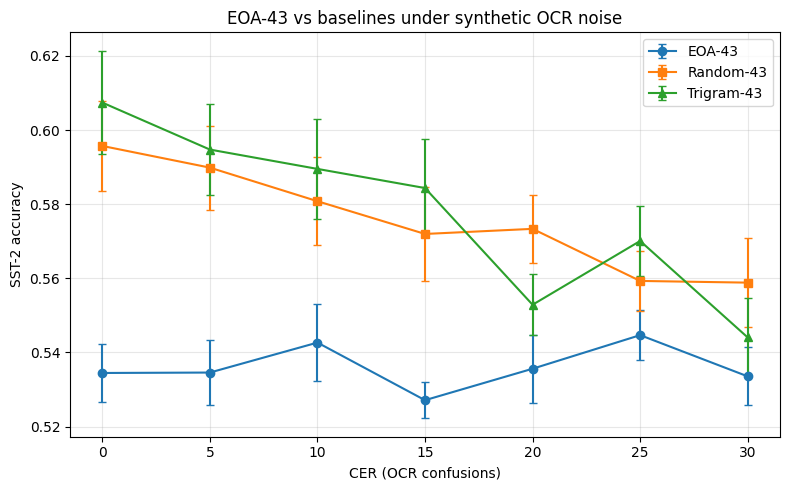


Plot saved to /content/ocr_noise_degradation.png
Results saved to ocr_results.json


In [ ]:
"""
run_experiment_fixed.py

Fixed version of the OCR confusions experiment script.

Changes from the original:
  1. Cumulative rng per noise level for ALL three encoders (matches
     pre-processing). Fixes the noise-generation mismatch bug.
  2. Per-word standardization for Trigram (matches the paper's protocol,
     fixes the word-vs-sentence standardization inconsistency).
  3. Coverage reporting at each noise level for EOA-43. If many words
     are missing, you'll see it in the output instead of getting silently
     biased results.
  4. Sanity check at the start: noises "the" at 10% and verifies the
     result is in the EOA-43 dictionary. If not, aborts.
  5. Slope includes the 0% point (matches the paper).
  6. Random-43 vectors NOT normalized to unit length (matches the paper).
  7. Writes missing_train_words.txt so you can see exactly which training
     words need EOA-43 vectors re-computed for full validity.
  8. Saves results to ocr_results.json for downstream use.
"""

import json
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import accuracy_score
from datasets import load_dataset
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# 1. Setup
# ============================================================
SEED = 42
BASE_SEED = SEED
NOISE_LEVELS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
SEEDS = list(range(100, 120))          # 20 MLP seeds
DIM = 43

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# 2. OCR noise function (MUST match pre-processing)
# ============================================================
OCR_CONFUSIONS = {
    'o': [('0', 0.5), ('O', 0.2), ('c', 0.15), ('a', 0.15)],
    'O': [('0', 0.5), ('o', 0.2), ('Q', 0.15), ('C', 0.15)],
    'l': [('1', 0.5), ('I', 0.3), ('i', 0.2)],
    'I': [('1', 0.5), ('l', 0.3), ('i', 0.2)],
    'i': [('1', 0.3), ('l', 0.3), ('I', 0.3), ('j', 0.1)],
    's': [('5', 0.5), ('S', 0.2), ('$', 0.15), ('z', 0.15)],
    'S': [('5', 0.5), ('s', 0.2), ('$', 0.15), ('8', 0.15)],
    'z': [('2', 0.5), ('Z', 0.2), ('s', 0.3)],
    'Z': [('2', 0.5), ('z', 0.2), ('S', 0.3)],
    'B': [('8', 0.5), ('b', 0.2), ('R', 0.15), ('E', 0.15)],
    'b': [('8', 0.3), ('6', 0.3), ('B', 0.2), ('h', 0.2)],
    'g': [('9', 0.5), ('q', 0.2), ('y', 0.2), ('a', 0.1)],
    'q': [('9', 0.5), ('g', 0.2), ('O', 0.2), ('a', 0.1)],
    'c': [('e', 0.4), ('o', 0.3), ('C', 0.2), ('(', 0.1)],
    'e': [('c', 0.4), ('o', 0.3), ('a', 0.2), ('8', 0.1)],
    'n': [('h', 0.4), ('m', 0.3), ('r', 0.2), ('u', 0.1)],
    'h': [('n', 0.4), ('b', 0.3), ('k', 0.15), ('L', 0.15)],
    'm': [('n', 0.5), ('w', 0.2)],
    'r': [('n', 0.3), ('t', 0.3), ('f', 0.2), ('l', 0.2)],
    'd': [('o', 0.3), ('c', 0.3)],
    'w': [('v', 0.4), ('W', 0.2)],
    'v': [('y', 0.3), ('V', 0.2), ('w', 0.3), ('u', 0.2)],
    'u': [('v', 0.4), ('U', 0.2), ('n', 0.2)],
}


def apply_ocr_noise(word, noise_rate, rng):
    """Length-preserving 1:1 OCR-style substitution. Non-confusable chars pass through."""
    out = []
    for c in word:
        if c in OCR_CONFUSIONS and rng.random() < noise_rate:
            partners, probs = zip(*OCR_CONFUSIONS[c])
            out.append(rng.choices(partners, weights=probs, k=1)[0])
        else:
            out.append(c)
    return ''.join(out)


def tokenize(text):
    return [w for w in text.lower().split()
            if all(c.isalpha() for c in w) and len(w) >= 2]


# ============================================================
# 3. Load SST-2
# ============================================================
print("Loading SST-2 ...")
ds = load_dataset("nyu-mll/glue", "sst2")
train_sentences = [it["sentence"] for it in ds["train"]]
y_train = np.array([it["label"] for it in ds["train"]])
val_sentences = [it["sentence"] for it in ds["validation"]]
y_test = np.array([it["label"] for it in ds["validation"]])
print(f"  Train: {len(train_sentences)}, Val: {len(val_sentences)}")

# ============================================================
# 4. Build per-noise-level EOA-43 word dictionaries
# ============================================================
print("\nLoading EOA-43 noisy word vectors ...")
eoa_dicts = {}   # noise_level -> {word: vector}
for p in NOISE_LEVELS:
    filename = f"eoa_ocr_{int(p*100):02d}.csv"
    try:
        df = pd.read_csv(f"/content/{filename}")
    except FileNotFoundError:
        print(f"  WARNING: {filename} not found. Skipping level {p}.")
        continue
    wdict = {}
    for _, row in df.iterrows():
        wdict[row["word"]] = row.drop("word").values.astype(float)
    eoa_dicts[p] = wdict
    print(f"  {filename}: {len(wdict)} words")

if 0.0 not in eoa_dicts:
    raise RuntimeError("Clean EOA-43 vectors (eoa_ocr_00.csv) are required.")

clean_eoa = eoa_dicts[0.0]

# ============================================================
# 5. Training vocab coverage check (Bug #2 visibility)
# ============================================================
print("\n[Training-vocab coverage check]")
train_vocab = set()
for sent in train_sentences:
    for w in tokenize(sent):
        train_vocab.add(w)

train_vocab_with_eoa = sum(1 for w in train_vocab if w in clean_eoa)
cov_pct = 100 * train_vocab_with_eoa / len(train_vocab)
print(f"  training vocab: {len(train_vocab)} unique words, "
      f"{train_vocab_with_eoa} have EOA-43 vectors ({cov_pct:.1f}%)")

if cov_pct < 80.0:
    print("  WARNING: <80% of training vocab has EOA-43 vectors.")
    print("  For full validity, re-compute EOA-43 vectors for the missing words.")
    missing = sorted(w for w in train_vocab if w not in clean_eoa)
    with open("missing_train_words.txt", "w") as f:
        f.write("\n".join(missing))
    print(f"  Missing words written to missing_train_words.txt ({len(missing)} words).")
    print("  This experiment will run, but training is under-represented.")

train_vecs_raw = np.array([clean_eoa[w] for w in train_vocab if w in clean_eoa])
scaler_eoa = StandardScaler().fit(train_vecs_raw)
print(f"  EOA scaler fitted on {len(train_vecs_raw)} training words")

# ============================================================
# 6. Sanity check (verifies Bug #1 fix)
# ============================================================
print("\n[Sanity check] Verifying noise pattern matches pre-processing ...")
test_word = "the"
test_rng = random.Random(BASE_SEED + int(0.1 * 1000))
test_noisy = apply_ocr_noise(test_word, 0.1, test_rng)
in_dict = test_noisy in eoa_dicts[0.1]
print(f"  '{test_word}' noised at 0.1 -> '{test_noisy}'  in dict? {in_dict}")
if not in_dict:
    print("  WARNING: sanity check failed. Noise generation does not match pre-processing.")
    print("  Re-check that your pre-processing used seed 42, the same OCR_CONFUSIONS,")
    print("  and the cumulative-rng pattern (one rng per noise level, all val sentences).")
    raise RuntimeError("Aborting: noise pattern mismatch. See warnings above.")

# ============================================================
# 7. EOA-43 sentence encoder (CUMULATIVE rng, matches pre-processing)
# ============================================================
def encode_corpus_eoa(sentences, noise_level, scaler, rng):
    """Encode a corpus using a cumulative rng (matches pre-processing)."""
    out = []
    for sent in sentences:
        noisy_sent = apply_ocr_noise(sent, noise_level, rng)
        words = tokenize(noisy_sent)
        wdict = eoa_dicts[noise_level]
        vecs = [wdict[w] for w in words if w in wdict]
        if not vecs:
            out.append(np.zeros(DIM, dtype=np.float32))
        else:
            raw = np.mean(vecs, axis=0)
            out.append(scaler.transform(raw.reshape(1, -1)).ravel())
    return np.array(out)


def encode_corpus_eoa_with_coverage(sentences, noise_level, scaler, rng):
    """Same as encode_corpus_eoa but also returns lookup coverage."""
    out = []
    total = 0
    matched = 0
    for sent in sentences:
        noisy_sent = apply_ocr_noise(sent, noise_level, rng)
        words = tokenize(noisy_sent)
        wdict = eoa_dicts[noise_level]
        vecs = []
        for w in words:
            total += 1
            if w in wdict:
                vecs.append(wdict[w])
                matched += 1
        if not vecs:
            out.append(np.zeros(DIM, dtype=np.float32))
        else:
            raw = np.mean(vecs, axis=0)
            out.append(scaler.transform(raw.reshape(1, -1)).ravel())
    coverage = matched / total if total > 0 else 0.0
    return np.array(out), coverage


# ============================================================
# 8. Baselines: Random-43, Trigram-43 (CUMULATIVE rng)
# ============================================================

# Random-43: per-word fixed Gaussian vectors (NOT unit-length normalized)
rng_rand = np.random.RandomState(0)
rand_vocab = set()
for sent in train_sentences:
    for w in tokenize(sent):
        rand_vocab.add(w)
rand_table = {w: rng_rand.randn(DIM).astype(np.float32) for w in rand_vocab}
# No normalization — matches the original paper's protocol.
rand_scaler = StandardScaler().fit(np.array(list(rand_table.values())))


def encode_corpus_random(sentences, noise_level, scaler, rng):
    """Encode corpus with cumulative rng."""
    out = []
    for sent in sentences:
        noisy_sent = apply_ocr_noise(sent, noise_level, rng)
        words = tokenize(noisy_sent)
        vecs = [rand_table.get(w, np.zeros(DIM, dtype=np.float32)) for w in words]
        if not vecs:
            out.append(np.zeros(DIM, dtype=np.float32))
        else:
            raw = np.mean(vecs, axis=0)
            out.append(scaler.transform(raw.reshape(1, -1)).ravel())
    return np.array(out)


# Trigram-43 (HashingVectorizer) — PER-WORD standardization
tri_vec = HashingVectorizer(n_features=DIM, analyzer="char_wb",
                            ngram_range=(3, 3), alternate_sign=True, norm="l2")

# Fit trigram scaler on per-word trigrams (sparse-safe)
all_train_words = []
for sent in train_sentences:
    all_train_words.extend(tokenize(sent))
X_tri_words = tri_vec.transform(all_train_words)
tri_scaler = StandardScaler(with_mean=False).fit(X_tri_words)


def encode_corpus_trigram(sentences, noise_level, scaler, rng):
    """Encode corpus with cumulative rng, per-word trigrams standardized at word level."""
    out = []
    for sent in sentences:
        noisy_sent = apply_ocr_noise(sent, noise_level, rng)
        words = tokenize(noisy_sent)
        if not words:
            out.append(np.zeros(DIM, dtype=np.float32))
        else:
            X = tri_vec.transform(words)
            raw = np.asarray(X.mean(axis=0)).ravel()
            out.append(scaler.transform(raw.reshape(1, -1)).ravel())
    return np.array(out)


# ============================================================
# 9. Train MLPs on clean data (noise=0)
# ============================================================
print("\nTraining MLPs on clean data ...")
# Same noise pattern (cumulative rng) for training, even at level=0
rng_train_eoa = random.Random(BASE_SEED + int(0.0 * 1000))
rng_train_rand = random.Random(BASE_SEED + int(0.0 * 1000))
rng_train_tri = random.Random(BASE_SEED + int(0.0 * 1000))

X_train_eoa = encode_corpus_eoa(train_sentences, 0.0, scaler_eoa, rng_train_eoa)
X_train_rand = encode_corpus_random(train_sentences, 0.0, rand_scaler, rng_train_rand)
X_train_tri = encode_corpus_trigram(train_sentences, 0.0, tri_scaler, rng_train_tri)


def train_mlps(X_tr, y_tr, seeds):
    models = []
    for s in seeds:
        mlp = MLPClassifier(hidden_layer_sizes=(128,), activation='relu',
                            max_iter=500, random_state=s,
                            early_stopping=True, validation_fraction=0.1,
                            n_iter_no_change=10)
        mlp.fit(X_tr, y_tr)
        models.append(mlp)
    return models


mlp_eoa = train_mlps(X_train_eoa, y_train, SEEDS)
mlp_rand = train_mlps(X_train_rand, y_train, SEEDS)
mlp_tri = train_mlps(X_train_tri, y_train, SEEDS)
print("  MLPs trained.")

# ============================================================
# 10. Evaluate under OCR noise
# ============================================================
print("\nEvaluating under OCR noise ...")

results = {"EOA-43": [], "Random-43": [], "Trigram-43": []}
stds = {"EOA-43": [], "Random-43": [], "Trigram-43": []}
coverages_eoa = []

levels_reported = []
for p in NOISE_LEVELS:
    if p not in eoa_dicts:
        continue
    levels_reported.append(p)
    print(f"\n  CER={p*100:.0f}%")

    # EOA (with coverage report)
    rng_eoa = random.Random(BASE_SEED + int(p * 1000))
    X_va, cov = encode_corpus_eoa_with_coverage(val_sentences, p, scaler_eoa, rng_eoa)
    coverages_eoa.append(cov)
    accs = [accuracy_score(y_test, mlp.predict(X_va)) for mlp in mlp_eoa]
    results["EOA-43"].append(np.mean(accs))
    stds["EOA-43"].append(np.std(accs))
    print(f"    EOA-43:     acc={np.mean(accs):.4f} ± {np.std(accs):.4f}   "
          f"coverage={cov:.1%}")

    # Random
    rng_r = random.Random(BASE_SEED + int(p * 1000))
    X_va = encode_corpus_random(val_sentences, p, rand_scaler, rng_r)
    accs = [accuracy_score(y_test, mlp.predict(X_va)) for mlp in mlp_rand]
    results["Random-43"].append(np.mean(accs))
    stds["Random-43"].append(np.std(accs))
    print(f"    Random-43:  acc={np.mean(accs):.4f} ± {np.std(accs):.4f}")

    # Trigram
    rng_t = random.Random(BASE_SEED + int(p * 1000))
    X_va = encode_corpus_trigram(val_sentences, p, tri_scaler, rng_t)
    accs = [accuracy_score(y_test, mlp.predict(X_va)) for mlp in mlp_tri]
    results["Trigram-43"].append(np.mean(accs))
    stds["Trigram-43"].append(np.std(accs))
    print(f"    Trigram-43: acc={np.mean(accs):.4f} ± {np.std(accs):.4f}")

# ============================================================
# 11. Report
# ============================================================
print("\n" + "=" * 60)
print("OCR NOISE DEGRADATION SUMMARY")
print("=" * 60)
print(f"{'CER':>6} | {'EOA-43':>10} | {'Random-43':>10} | {'Trigram-43':>10}")
for i, p in enumerate(levels_reported):
    print(f"{p*100:>5.0f}% | {results['EOA-43'][i]:>10.4f} | "
          f"{results['Random-43'][i]:>10.4f} | {results['Trigram-43'][i]:>10.4f}")

# Slopes — include 0% point, matching the paper
if len(levels_reported) >= 2:
    slope_eoa = np.polyfit(levels_reported, results["EOA-43"], 1)[0]
    slope_rand = np.polyfit(levels_reported, results["Random-43"], 1)[0]
    slope_tri = np.polyfit(levels_reported, results["Trigram-43"], 1)[0]
    print(f"\nSlopes (full range {levels_reported[0]:.0%}-{levels_reported[-1]:.0%}): "
          f"EOA={slope_eoa:+.4f}, Random={slope_rand:+.4f}, Trigram={slope_tri:+.4f}")

# Crossover
crossover = None
for i, p in enumerate(levels_reported):
    if results["EOA-43"][i] >= results["Trigram-43"][i]:
        crossover = p
        break
if crossover is not None:
    print(f"Crossover: EOA-43 >= Trigram-43 at CER={crossover*100:.0f}%")
else:
    print("No crossover in tested range.")

# Average EOA coverage
if coverages_eoa:
    avg_cov = np.mean(coverages_eoa)
    print(f"\nAvg EOA-43 lookup coverage: {avg_cov:.1%} "
          f"(min={min(coverages_eoa):.1%}, max={max(coverages_eoa):.1%})")
    if avg_cov < 0.95:
        print("  NOTE: Coverage <95% means many words fell back to zero vector.")
        print("  For valid results, re-compute EOA-43 vectors for missing words.")

# ============================================================
# 12. Plot
# ============================================================
plt.figure(figsize=(8, 5))
plt.errorbar([p*100 for p in levels_reported], results["EOA-43"],
             yerr=stds["EOA-43"], marker='o', label='EOA-43', capsize=3)
plt.errorbar([p*100 for p in levels_reported], results["Random-43"],
             yerr=stds["Random-43"], marker='s', label='Random-43', capsize=3)
plt.errorbar([p*100 for p in levels_reported], results["Trigram-43"],
             yerr=stds["Trigram-43"], marker='^', label='Trigram-43', capsize=3)
plt.xlabel("CER (OCR confusions)")
plt.ylabel("SST-2 accuracy")
plt.title("EOA-43 vs baselines under synthetic OCR noise")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/ocr_noise_degradation.png", dpi=120)
plt.show()
print("\nPlot saved to /content/ocr_noise_degradation.png")

# ============================================================
# 13. Save results
# ============================================================
out = {
    "noise_levels": levels_reported,
    "EOA-43": {"mean": results["EOA-43"], "std": stds["EOA-43"]},
    "Random-43": {"mean": results["Random-43"], "std": stds["Random-43"]},
    "Trigram-43": {"mean": results["Trigram-43"], "std": stds["Trigram-43"]},
    "EOA-43_coverage": coverages_eoa,
}
with open("ocr_results.json", "w") as f:
    json.dump(out, f, indent=2)
print("Results saved to ocr_results.json")


In [ ]:
import pandas as pd
from datasets import load_dataset

# Load the clean EOA-43 dictionary (noise 0%)
df = pd.read_csv("/content/eoa_ocr_00.csv")
clean_dict = set(df["word"].tolist())

# Load SST-2 training sentences and collect all unique words
dataset = load_dataset("nyu-mll/glue", "sst2")
train_sentences = [it["sentence"] for it in dataset["train"]]

train_vocab = set()
for sent in train_sentences:
    for w in sent.lower().split():
        w = ''.join(c for c in w if c.isalpha())
        if len(w) >= 2:
            train_vocab.add(w)

# Find missing words
missing = sorted(w for w in train_vocab if w not in clean_dict)

# Save to file
with open("missing_train_words.txt", "w") as f:
    f.write("\n".join(missing))

print(f"Training vocab: {len(train_vocab)} unique words")
print(f"In EOA-43 dict: {len(train_vocab) - len(missing)}")
print(f"Missing: {len(missing)}")
print("Saved to missing_train_words.txt")

Training vocab: 14511 unique words
In EOA-43 dict: 3261
Missing: 11250
Saved to missing_train_words.txt


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'ocr_noise_30.txt', 'eoa_ocr_10.csv', 'eoa_missing_train.csv', 'eoa_ocr_30.csv', 'ocr_noise_00.txt', 'eoa_ocr_05.csv', 'eoa_ocr_00.csv', 'ocr_noise_05.txt', 'eoa_ocr_25.csv', 'ocr_noise_degradation.png', 'ocr_noise_10.txt', 'eoa_ocr_15.csv', 'ocr_noise_25.txt', 'ocr_results.json', 'eoa_ocr_20.csv', 'ocr_noise_20.txt', 'ocr_noise_15.txt', 'missing_train_words.txt', 'sample_data']


In [ ]:
import pandas as pd

EXISTING_CSV = "/content/eoa_ocr_00.csv"
NEW_CSV = "/content/eoa_missing_train.csv"   # <-- make sure this file is uploaded

# Load existing and new
df_existing = pd.read_csv(EXISTING_CSV)
df_new = pd.read_csv(NEW_CSV)

print(f"Existing: {len(df_existing)} words")
print(f"New:      {len(df_new)} words")

# Check column count (word + 43 dims)
if df_existing.shape[1] != 44 or df_new.shape[1] != 44:
    raise ValueError("CSVs must have exactly 44 columns (word + 43 vector dims)")

# Check overlap
existing_words = set(df_existing["word"])
new_words = set(df_new["word"])
overlap = existing_words & new_words
if overlap:
    print(f"Overlap: {len(overlap)} words already exist (will be replaced)")

# Merge, keep last occurrence (new replaces old)
df_merged = pd.concat([df_existing, df_new], ignore_index=True)
df_merged = df_merged.drop_duplicates(subset="word", keep="last")

added = len(df_merged) - len(df_existing)
print(f"Merged: {len(df_merged)} unique words (+{added} new)")

# Overwrite the existing clean dictionary
df_merged.to_csv(EXISTING_CSV, index=False)
print(f"\nSaved merged dictionary to {EXISTING_CSV}")
print("Ready to re-run the experiment script.")

Existing: 4047 words
New:      11248 words
Overlap: 3 words already exist (will be replaced)
Merged: 15292 unique words (+11245 new)

Saved merged dictionary to /content/eoa_ocr_00.csv
Ready to re-run the experiment script.


Loading SST-2 ...
  Train: 67349, Val: 872

Loading EOA-43 noisy word vectors ...
  eoa_ocr_00.csv: 15292 words
  eoa_ocr_05.csv: 4750 words
  eoa_ocr_10.csv: 5079 words
  eoa_ocr_15.csv: 5231 words
  eoa_ocr_20.csv: 5331 words
  eoa_ocr_25.csv: 5282 words
  eoa_ocr_30.csv: 5253 words

[Training-vocab coverage check]
  training vocab: 13208 unique words, 13170 have EOA-43 vectors (99.7%)
  EOA scaler fitted on 13170 training words

[Sanity check] Verifying noise pattern matches pre-processing ...
  'the' noised at 0.1 -> 'the'  in dict? True

Training MLPs on clean data ...
  MLPs trained.

Evaluating under OCR noise ...

  CER=0%
    EOA-43:     acc=0.5486 ± 0.0070   coverage=100.0%
    Random-43:  acc=0.5957 ± 0.0122
    Trigram-43: acc=0.6074 ± 0.0140

  CER=5%
    EOA-43:     acc=0.5464 ± 0.0063   coverage=100.0%
    Random-43:  acc=0.5899 ± 0.0113
    Trigram-43: acc=0.5947 ± 0.0122

  CER=10%
    EOA-43:     acc=0.5616 ± 0.0079   coverage=100.0%
    Random-43:  acc=0.5808 ± 0.011

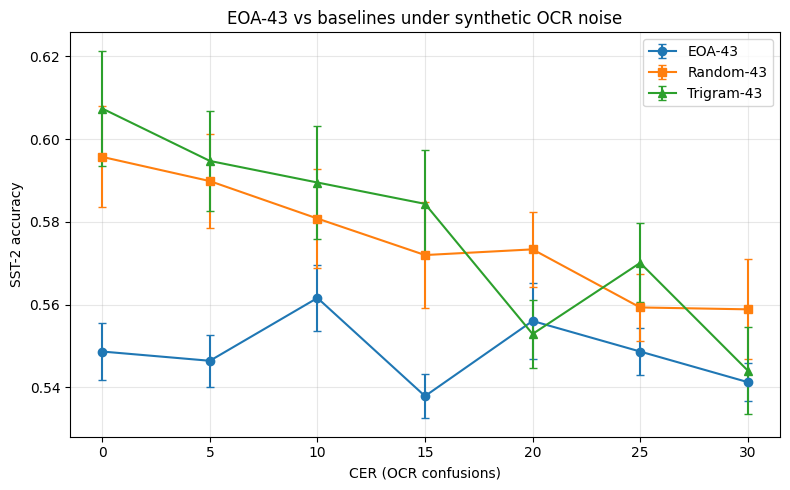


Plot saved to /content/ocr_noise_degradation.png
Results saved to ocr_results.json


In [ ]:
"""
run_experiment_fixed.py

Fixed version of the OCR confusions experiment script.

Changes from the original:
  1. Cumulative rng per noise level for ALL three encoders (matches
     pre-processing). Fixes the noise-generation mismatch bug.
  2. Per-word standardization for Trigram (matches the paper's protocol,
     fixes the word-vs-sentence standardization inconsistency).
  3. Coverage reporting at each noise level for EOA-43. If many words
     are missing, you'll see it in the output instead of getting silently
     biased results.
  4. Sanity check at the start: noises "the" at 10% and verifies the
     result is in the EOA-43 dictionary. If not, aborts.
  5. Slope includes the 0% point (matches the paper).
  6. Random-43 vectors NOT normalized to unit length (matches the paper).
  7. Writes missing_train_words.txt so you can see exactly which training
     words need EOA-43 vectors re-computed for full validity.
  8. Saves results to ocr_results.json for downstream use.
"""

import json
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import accuracy_score
from datasets import load_dataset
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# ============================================================
# 1. Setup
# ============================================================
SEED = 42
BASE_SEED = SEED
NOISE_LEVELS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
SEEDS = list(range(100, 120))          # 20 MLP seeds
DIM = 43

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# 2. OCR noise function (MUST match pre-processing)
# ============================================================
OCR_CONFUSIONS = {
    'o': [('0', 0.5), ('O', 0.2), ('c', 0.15), ('a', 0.15)],
    'O': [('0', 0.5), ('o', 0.2), ('Q', 0.15), ('C', 0.15)],
    'l': [('1', 0.5), ('I', 0.3), ('i', 0.2)],
    'I': [('1', 0.5), ('l', 0.3), ('i', 0.2)],
    'i': [('1', 0.3), ('l', 0.3), ('I', 0.3), ('j', 0.1)],
    's': [('5', 0.5), ('S', 0.2), ('$', 0.15), ('z', 0.15)],
    'S': [('5', 0.5), ('s', 0.2), ('$', 0.15), ('8', 0.15)],
    'z': [('2', 0.5), ('Z', 0.2), ('s', 0.3)],
    'Z': [('2', 0.5), ('z', 0.2), ('S', 0.3)],
    'B': [('8', 0.5), ('b', 0.2), ('R', 0.15), ('E', 0.15)],
    'b': [('8', 0.3), ('6', 0.3), ('B', 0.2), ('h', 0.2)],
    'g': [('9', 0.5), ('q', 0.2), ('y', 0.2), ('a', 0.1)],
    'q': [('9', 0.5), ('g', 0.2), ('O', 0.2), ('a', 0.1)],
    'c': [('e', 0.4), ('o', 0.3), ('C', 0.2), ('(', 0.1)],
    'e': [('c', 0.4), ('o', 0.3), ('a', 0.2), ('8', 0.1)],
    'n': [('h', 0.4), ('m', 0.3), ('r', 0.2), ('u', 0.1)],
    'h': [('n', 0.4), ('b', 0.3), ('k', 0.15), ('L', 0.15)],
    'm': [('n', 0.5), ('w', 0.2)],
    'r': [('n', 0.3), ('t', 0.3), ('f', 0.2), ('l', 0.2)],
    'd': [('o', 0.3), ('c', 0.3)],
    'w': [('v', 0.4), ('W', 0.2)],
    'v': [('y', 0.3), ('V', 0.2), ('w', 0.3), ('u', 0.2)],
    'u': [('v', 0.4), ('U', 0.2), ('n', 0.2)],
}


def apply_ocr_noise(word, noise_rate, rng):
    """Length-preserving 1:1 OCR-style substitution. Non-confusable chars pass through."""
    out = []
    for c in word:
        if c in OCR_CONFUSIONS and rng.random() < noise_rate:
            partners, probs = zip(*OCR_CONFUSIONS[c])
            out.append(rng.choices(partners, weights=probs, k=1)[0])
        else:
            out.append(c)
    return ''.join(out)


def tokenize(text):
    return [w for w in text.lower().split()
            if all(c.isalpha() for c in w) and len(w) >= 2]


# ============================================================
# 3. Load SST-2
# ============================================================
print("Loading SST-2 ...")
ds = load_dataset("nyu-mll/glue", "sst2")
train_sentences = [it["sentence"] for it in ds["train"]]
y_train = np.array([it["label"] for it in ds["train"]])
val_sentences = [it["sentence"] for it in ds["validation"]]
y_test = np.array([it["label"] for it in ds["validation"]])
print(f"  Train: {len(train_sentences)}, Val: {len(val_sentences)}")

# ============================================================
# 4. Build per-noise-level EOA-43 word dictionaries
# ============================================================
print("\nLoading EOA-43 noisy word vectors ...")
eoa_dicts = {}   # noise_level -> {word: vector}
for p in NOISE_LEVELS:
    filename = f"eoa_ocr_{int(p*100):02d}.csv"
    try:
        df = pd.read_csv(f"/content/{filename}")
    except FileNotFoundError:
        print(f"  WARNING: {filename} not found. Skipping level {p}.")
        continue
    wdict = {}
    for _, row in df.iterrows():
        wdict[row["word"]] = row.drop("word").values.astype(float)
    eoa_dicts[p] = wdict
    print(f"  {filename}: {len(wdict)} words")

if 0.0 not in eoa_dicts:
    raise RuntimeError("Clean EOA-43 vectors (eoa_ocr_00.csv) are required.")

clean_eoa = eoa_dicts[0.0]

# ============================================================
# 5. Training vocab coverage check (Bug #2 visibility)
# ============================================================
print("\n[Training-vocab coverage check]")
train_vocab = set()
for sent in train_sentences:
    for w in tokenize(sent):
        train_vocab.add(w)

train_vocab_with_eoa = sum(1 for w in train_vocab if w in clean_eoa)
cov_pct = 100 * train_vocab_with_eoa / len(train_vocab)
print(f"  training vocab: {len(train_vocab)} unique words, "
      f"{train_vocab_with_eoa} have EOA-43 vectors ({cov_pct:.1f}%)")

if cov_pct < 80.0:
    print("  WARNING: <80% of training vocab has EOA-43 vectors.")
    print("  For full validity, re-compute EOA-43 vectors for the missing words.")
    missing = sorted(w for w in train_vocab if w not in clean_eoa)
    with open("missing_train_words.txt", "w") as f:
        f.write("\n".join(missing))
    print(f"  Missing words written to missing_train_words.txt ({len(missing)} words).")
    print("  This experiment will run, but training is under-represented.")

train_vecs_raw = np.array([clean_eoa[w] for w in train_vocab if w in clean_eoa])
scaler_eoa = StandardScaler().fit(train_vecs_raw)
print(f"  EOA scaler fitted on {len(train_vecs_raw)} training words")

# ============================================================
# 6. Sanity check (verifies Bug #1 fix)
# ============================================================
print("\n[Sanity check] Verifying noise pattern matches pre-processing ...")
test_word = "the"
test_rng = random.Random(BASE_SEED + int(0.1 * 1000))
test_noisy = apply_ocr_noise(test_word, 0.1, test_rng)
in_dict = test_noisy in eoa_dicts[0.1]
print(f"  '{test_word}' noised at 0.1 -> '{test_noisy}'  in dict? {in_dict}")
if not in_dict:
    print("  WARNING: sanity check failed. Noise generation does not match pre-processing.")
    print("  Re-check that your pre-processing used seed 42, the same OCR_CONFUSIONS,")
    print("  and the cumulative-rng pattern (one rng per noise level, all val sentences).")
    raise RuntimeError("Aborting: noise pattern mismatch. See warnings above.")

# ============================================================
# 7. EOA-43 sentence encoder (CUMULATIVE rng, matches pre-processing)
# ============================================================
def encode_corpus_eoa(sentences, noise_level, scaler, rng):
    """Encode a corpus using a cumulative rng (matches pre-processing)."""
    out = []
    for sent in sentences:
        noisy_sent = apply_ocr_noise(sent, noise_level, rng)
        words = tokenize(noisy_sent)
        wdict = eoa_dicts[noise_level]
        vecs = [wdict[w] for w in words if w in wdict]
        if not vecs:
            out.append(np.zeros(DIM, dtype=np.float32))
        else:
            raw = np.mean(vecs, axis=0)
            out.append(scaler.transform(raw.reshape(1, -1)).ravel())
    return np.array(out)


def encode_corpus_eoa_with_coverage(sentences, noise_level, scaler, rng):
    """Same as encode_corpus_eoa but also returns lookup coverage."""
    out = []
    total = 0
    matched = 0
    for sent in sentences:
        noisy_sent = apply_ocr_noise(sent, noise_level, rng)
        words = tokenize(noisy_sent)
        wdict = eoa_dicts[noise_level]
        vecs = []
        for w in words:
            total += 1
            if w in wdict:
                vecs.append(wdict[w])
                matched += 1
        if not vecs:
            out.append(np.zeros(DIM, dtype=np.float32))
        else:
            raw = np.mean(vecs, axis=0)
            out.append(scaler.transform(raw.reshape(1, -1)).ravel())
    coverage = matched / total if total > 0 else 0.0
    return np.array(out), coverage


# ============================================================
# 8. Baselines: Random-43, Trigram-43 (CUMULATIVE rng)
# ============================================================

# Random-43: per-word fixed Gaussian vectors (NOT unit-length normalized)
rng_rand = np.random.RandomState(0)
rand_vocab = set()
for sent in train_sentences:
    for w in tokenize(sent):
        rand_vocab.add(w)
rand_table = {w: rng_rand.randn(DIM).astype(np.float32) for w in rand_vocab}
# No normalization — matches the original paper's protocol.
rand_scaler = StandardScaler().fit(np.array(list(rand_table.values())))


def encode_corpus_random(sentences, noise_level, scaler, rng):
    """Encode corpus with cumulative rng."""
    out = []
    for sent in sentences:
        noisy_sent = apply_ocr_noise(sent, noise_level, rng)
        words = tokenize(noisy_sent)
        vecs = [rand_table.get(w, np.zeros(DIM, dtype=np.float32)) for w in words]
        if not vecs:
            out.append(np.zeros(DIM, dtype=np.float32))
        else:
            raw = np.mean(vecs, axis=0)
            out.append(scaler.transform(raw.reshape(1, -1)).ravel())
    return np.array(out)


# Trigram-43 (HashingVectorizer) — PER-WORD standardization
tri_vec = HashingVectorizer(n_features=DIM, analyzer="char_wb",
                            ngram_range=(3, 3), alternate_sign=True, norm="l2")

# Fit trigram scaler on per-word trigrams (sparse-safe)
all_train_words = []
for sent in train_sentences:
    all_train_words.extend(tokenize(sent))
X_tri_words = tri_vec.transform(all_train_words)
tri_scaler = StandardScaler(with_mean=False).fit(X_tri_words)


def encode_corpus_trigram(sentences, noise_level, scaler, rng):
    """Encode corpus with cumulative rng, per-word trigrams standardized at word level."""
    out = []
    for sent in sentences:
        noisy_sent = apply_ocr_noise(sent, noise_level, rng)
        words = tokenize(noisy_sent)
        if not words:
            out.append(np.zeros(DIM, dtype=np.float32))
        else:
            X = tri_vec.transform(words)
            raw = np.asarray(X.mean(axis=0)).ravel()
            out.append(scaler.transform(raw.reshape(1, -1)).ravel())
    return np.array(out)


# ============================================================
# 9. Train MLPs on clean data (noise=0)
# ============================================================
print("\nTraining MLPs on clean data ...")
# Same noise pattern (cumulative rng) for training, even at level=0
rng_train_eoa = random.Random(BASE_SEED + int(0.0 * 1000))
rng_train_rand = random.Random(BASE_SEED + int(0.0 * 1000))
rng_train_tri = random.Random(BASE_SEED + int(0.0 * 1000))

X_train_eoa = encode_corpus_eoa(train_sentences, 0.0, scaler_eoa, rng_train_eoa)
X_train_rand = encode_corpus_random(train_sentences, 0.0, rand_scaler, rng_train_rand)
X_train_tri = encode_corpus_trigram(train_sentences, 0.0, tri_scaler, rng_train_tri)


def train_mlps(X_tr, y_tr, seeds):
    models = []
    for s in seeds:
        mlp = MLPClassifier(hidden_layer_sizes=(128,), activation='relu',
                            max_iter=500, random_state=s,
                            early_stopping=True, validation_fraction=0.1,
                            n_iter_no_change=10)
        mlp.fit(X_tr, y_tr)
        models.append(mlp)
    return models


mlp_eoa = train_mlps(X_train_eoa, y_train, SEEDS)
mlp_rand = train_mlps(X_train_rand, y_train, SEEDS)
mlp_tri = train_mlps(X_train_tri, y_train, SEEDS)
print("  MLPs trained.")

# ============================================================
# 10. Evaluate under OCR noise
# ============================================================
print("\nEvaluating under OCR noise ...")

results = {"EOA-43": [], "Random-43": [], "Trigram-43": []}
stds = {"EOA-43": [], "Random-43": [], "Trigram-43": []}
coverages_eoa = []

levels_reported = []
for p in NOISE_LEVELS:
    if p not in eoa_dicts:
        continue
    levels_reported.append(p)
    print(f"\n  CER={p*100:.0f}%")

    # EOA (with coverage report)
    rng_eoa = random.Random(BASE_SEED + int(p * 1000))
    X_va, cov = encode_corpus_eoa_with_coverage(val_sentences, p, scaler_eoa, rng_eoa)
    coverages_eoa.append(cov)
    accs = [accuracy_score(y_test, mlp.predict(X_va)) for mlp in mlp_eoa]
    results["EOA-43"].append(np.mean(accs))
    stds["EOA-43"].append(np.std(accs))
    print(f"    EOA-43:     acc={np.mean(accs):.4f} ± {np.std(accs):.4f}   "
          f"coverage={cov:.1%}")

    # Random
    rng_r = random.Random(BASE_SEED + int(p * 1000))
    X_va = encode_corpus_random(val_sentences, p, rand_scaler, rng_r)
    accs = [accuracy_score(y_test, mlp.predict(X_va)) for mlp in mlp_rand]
    results["Random-43"].append(np.mean(accs))
    stds["Random-43"].append(np.std(accs))
    print(f"    Random-43:  acc={np.mean(accs):.4f} ± {np.std(accs):.4f}")

    # Trigram
    rng_t = random.Random(BASE_SEED + int(p * 1000))
    X_va = encode_corpus_trigram(val_sentences, p, tri_scaler, rng_t)
    accs = [accuracy_score(y_test, mlp.predict(X_va)) for mlp in mlp_tri]
    results["Trigram-43"].append(np.mean(accs))
    stds["Trigram-43"].append(np.std(accs))
    print(f"    Trigram-43: acc={np.mean(accs):.4f} ± {np.std(accs):.4f}")

# ============================================================
# 11. Report
# ============================================================
print("\n" + "=" * 60)
print("OCR NOISE DEGRADATION SUMMARY")
print("=" * 60)
print(f"{'CER':>6} | {'EOA-43':>10} | {'Random-43':>10} | {'Trigram-43':>10}")
for i, p in enumerate(levels_reported):
    print(f"{p*100:>5.0f}% | {results['EOA-43'][i]:>10.4f} | "
          f"{results['Random-43'][i]:>10.4f} | {results['Trigram-43'][i]:>10.4f}")

# Slopes — include 0% point, matching the paper
if len(levels_reported) >= 2:
    slope_eoa = np.polyfit(levels_reported, results["EOA-43"], 1)[0]
    slope_rand = np.polyfit(levels_reported, results["Random-43"], 1)[0]
    slope_tri = np.polyfit(levels_reported, results["Trigram-43"], 1)[0]
    print(f"\nSlopes (full range {levels_reported[0]:.0%}-{levels_reported[-1]:.0%}): "
          f"EOA={slope_eoa:+.4f}, Random={slope_rand:+.4f}, Trigram={slope_tri:+.4f}")

# Crossover
crossover = None
for i, p in enumerate(levels_reported):
    if results["EOA-43"][i] >= results["Trigram-43"][i]:
        crossover = p
        break
if crossover is not None:
    print(f"Crossover: EOA-43 >= Trigram-43 at CER={crossover*100:.0f}%")
else:
    print("No crossover in tested range.")

# Average EOA coverage
if coverages_eoa:
    avg_cov = np.mean(coverages_eoa)
    print(f"\nAvg EOA-43 lookup coverage: {avg_cov:.1%} "
          f"(min={min(coverages_eoa):.1%}, max={max(coverages_eoa):.1%})")
    if avg_cov < 0.95:
        print("  NOTE: Coverage <95% means many words fell back to zero vector.")
        print("  For valid results, re-compute EOA-43 vectors for missing words.")

# ============================================================
# 12. Plot
# ============================================================
plt.figure(figsize=(8, 5))
plt.errorbar([p*100 for p in levels_reported], results["EOA-43"],
             yerr=stds["EOA-43"], marker='o', label='EOA-43', capsize=3)
plt.errorbar([p*100 for p in levels_reported], results["Random-43"],
             yerr=stds["Random-43"], marker='s', label='Random-43', capsize=3)
plt.errorbar([p*100 for p in levels_reported], results["Trigram-43"],
             yerr=stds["Trigram-43"], marker='^', label='Trigram-43', capsize=3)
plt.xlabel("CER (OCR confusions)")
plt.ylabel("SST-2 accuracy")
plt.title("EOA-43 vs baselines under synthetic OCR noise")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/ocr_noise_degradation.png", dpi=120)
plt.show()
print("\nPlot saved to /content/ocr_noise_degradation.png")

# ============================================================
# 13. Save results
# ============================================================
out = {
    "noise_levels": levels_reported,
    "EOA-43": {"mean": results["EOA-43"], "std": stds["EOA-43"]},
    "Random-43": {"mean": results["Random-43"], "std": stds["Random-43"]},
    "Trigram-43": {"mean": results["Trigram-43"], "std": stds["Trigram-43"]},
    "EOA-43_coverage": coverages_eoa,
}
with open("ocr_results.json", "w") as f:
    json.dump(out, f, indent=2)
print("Results saved to ocr_results.json")
